In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Data/Solar Power Plant Data.csv')

df['Date-Hour(NMT)'] = pd.to_datetime(
    df['Date-Hour(NMT)'],
    format='%d.%m.%Y-%H:%M'
)

df['Hour'] = df['Date-Hour(NMT)'].dt.hour
df['Month'] = df['Date-Hour(NMT)'].dt.month

In [5]:
X = df.drop(columns=['SystemProduction', 'Date-Hour(NMT)'])
y = df['SystemProduction']

In [6]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [8]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

baseline_prediction = np.full(len(y_test), y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_r2 = r2_score(y_test, baseline_prediction)

print("Baseline MAE:", baseline_mae)
print("Baseline R²:", baseline_r2)

Baseline MAE: 799.8529711184932
Baseline R²: -6.026099984136323


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np


linear_model = LinearRegression()

linear_model.fit(X_train, y_train)


y_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, y_pred)
linear_r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("R²:", linear_r2)

Linear Regression Results
MAE: 229.02955940074855
R²: -0.11395654745524597


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("R²:", rf_r2)

Random Forest Results
MAE: 95.5364296655251
R²: 0.22264915923302553


In [12]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Linear Regression', 'Random Forest'],
    'MAE': [baseline_mae, linear_mae, rf_mae],
    'R²': [baseline_r2, linear_r2, rf_r2]
})

results

,Model,MAE,R²
0,Baseline,799.852971,-6.026100
1,Linear Regression,229.029559,-0.113957
2,Random Forest,95.536430,0.222649


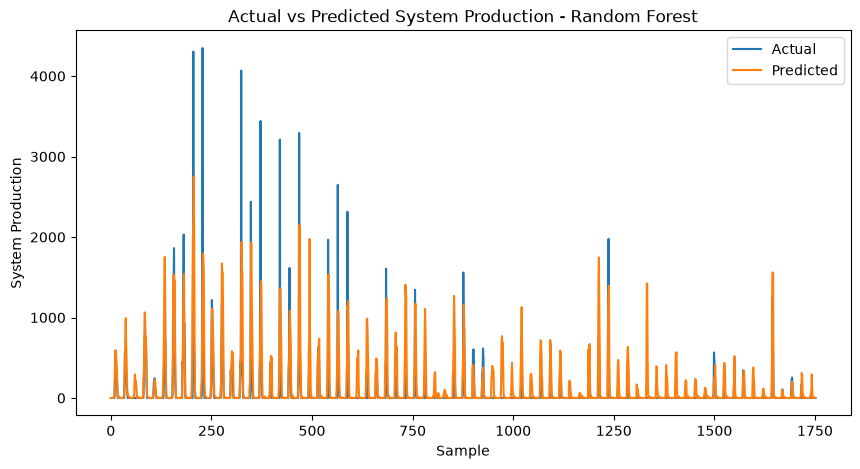

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(y_test.values, label='Actual')
plt.plot(rf_pred, label='Predicted')

plt.xlabel('Sample')
plt.ylabel('System Production')
plt.title('Actual vs Predicted System Production - Random Forest')
plt.legend()

plt.show()

In [15]:
rf_improved = RandomForestRegressor( n_estimators=200, random_state=42)

rf_improved.fit(X_train, y_train)

y_pred_improved = rf_improved.predict(X_test)

r2_improved = r2_score(y_test, y_pred_improved)

print("Improved Random Forest R²:", r2_improved)

Improved Random Forest R²: 0.20708335472140305


In [17]:
from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train, y_train)

print("Final model trained successfully!")

Final model trained successfully!


In [18]:
import joblib

joblib.dump(final_model, 'final_model.pkl')

print("Model saved successfully!")

Model saved successfully!
